<a href="https://colab.research.google.com/github/varthanharsh35-ux/24ADI003_24BAD033/blob/main/EX%208_SCENARIO%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 2 – Dimensionality Reduction using PCA


## 1. Load Dataset

In [13]:
print("Harshavardhan\n24BAD033")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target
print(f"Shape: {X.shape}")
X.head()


Harshavardhan
24BAD033
Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 2. Data Preprocessing – Handle Missing Values

In [2]:
"Missing values:", X.isnull().sum().sum()

('Missing values:', np.int64(0))

In [3]:
X.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


## 3. Standardize Features

PCA is sensitive to scale. Features with larger ranges dominate the variance calculation. Standardization (zero mean, unit variance) ensures all features contribute equally.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Mean (approx 0): {X_scaled.mean(axis=0).round(10)}")
print(f"Std  (approx 1): {X_scaled.std(axis=0).round(2)}")

Mean (approx 0): [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]
Std  (approx 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4 & 5. Apply PCA and Compute Principal Components

In [5]:
pca_full = PCA()
pca_full.fit(X_scaled)
print(f"Total components: {pca_full.n_components_}")

Total components: 13


## 6. Determine Explained Variance Ratio

In [6]:
evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)

ev_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(evr))],
    'Explained Variance (%)': (evr * 100).round(2),
    'Cumulative (%)': (cumulative * 100).round(2)
})
print(ev_df.to_string(index=False))

Component  Explained Variance (%)  Cumulative (%)
      PC1                   36.20           36.20
      PC2                   19.21           55.41
      PC3                   11.12           66.53
      PC4                    7.07           73.60
      PC5                    6.56           80.16
      PC6                    4.94           85.10
      PC7                    4.24           89.34
      PC8                    2.68           92.02
      PC9                    2.22           94.24
     PC10                    1.93           96.17
     PC11                    1.74           97.91
     PC12                    1.30           99.20
     PC13                    0.80          100.00


## 7. Reduce Dimensions to 2D and 3D

In [7]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)
print(f"2D variance captured: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)
print(f"3D variance captured: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

2D variance captured: 55.41%
3D variance captured: 66.53%


In [8]:
print(f"PC1 explains: {evr[0]*100:.2f}% of variance")
print(f"PC2 explains: {evr[1]*100:.2f}% of variance")
print(f"PC1+PC2 together: {cumulative[1]*100:.2f}%")
n_90 = np.argmax(cumulative >= 0.90) + 1
print(f"Components needed for 90% variance: {n_90}")

PC1 explains: 36.20% of variance
PC2 explains: 19.21% of variance
PC1+PC2 together: 55.41%
Components needed for 90% variance: 8


## Visualizations

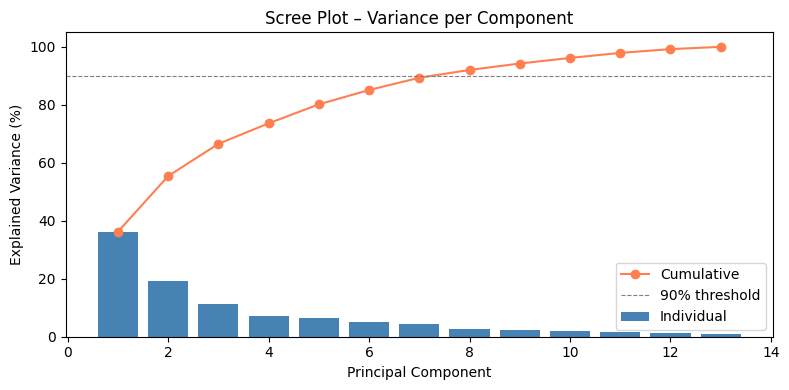

In [9]:
# Scree plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(evr)+1), evr * 100, color='steelblue', label='Individual')
plt.plot(range(1, len(evr)+1), cumulative * 100, marker='o', color='coral', label='Cumulative')
plt.axhline(90, linestyle='--', color='gray', linewidth=0.8, label='90% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot – Variance per Component')
plt.legend()
plt.tight_layout()
plt.show()

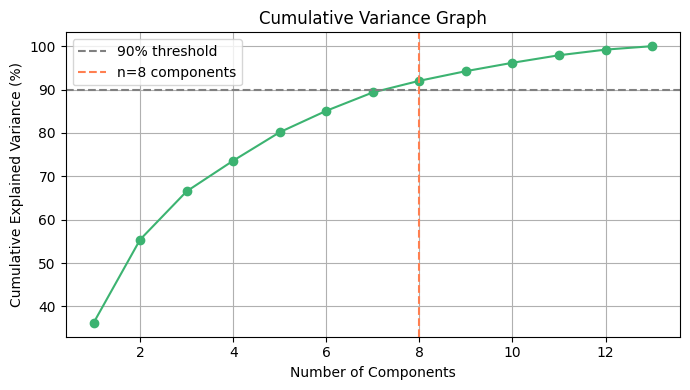

In [10]:
# Cumulative variance plot
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative)+1), cumulative * 100, marker='o', color='mediumseagreen')
plt.axhline(90, linestyle='--', color='gray', label='90% threshold')
plt.axvline(n_90, linestyle='--', color='coral', label=f'n={n_90} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Variance Graph')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

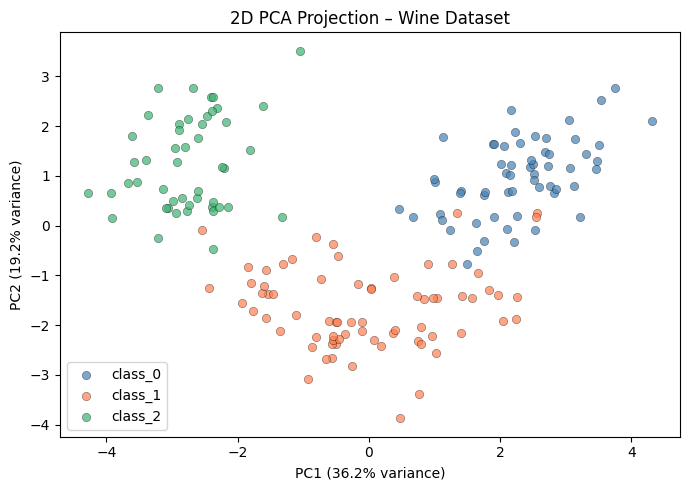

In [11]:
# 2D scatter plot of principal components
colors = ['steelblue', 'coral', 'mediumseagreen']
cultivars = wine.target_names

plt.figure(figsize=(7, 5))
for i, label in enumerate(cultivars):
    mask = y == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=label, color=colors[i], alpha=0.7, edgecolors='k', linewidths=0.3)

plt.xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
plt.title('2D PCA Projection – Wine Dataset')
plt.legend()
plt.tight_layout()
plt.show()

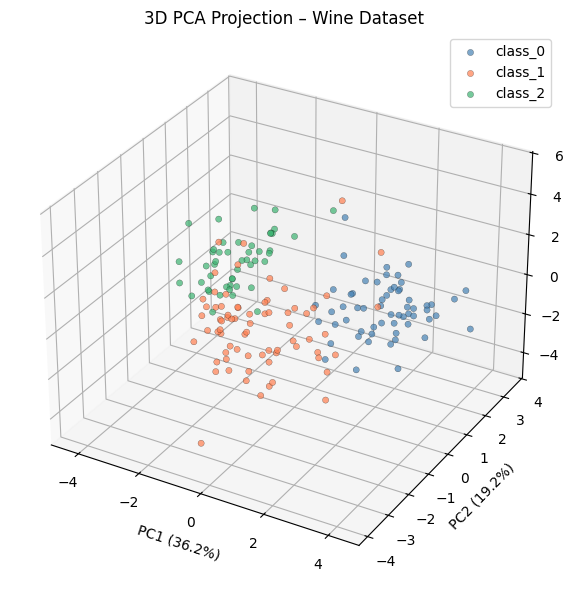

In [12]:
# 3D scatter plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for i, label in enumerate(cultivars):
    mask = y == i
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               label=label, color=colors[i], alpha=0.7, edgecolors='k', linewidths=0.2)

ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({evr[2]*100:.1f}%)')
ax.set_title('3D PCA Projection – Wine Dataset')
ax.legend()
plt.tight_layout()
plt.show()